# Notebook 10 — Federated Learning + Differential Privacy (Combined)

## What this notebook does
I combine FL (Flower) and DP (Opacus) into a single training pipeline: each client applies DP-SGD locally before sending weight updates to the FedAvg server. This is the **primary model** of the paper — FedAvg + DP.

## Why this step matters
Combining FL and DP requires careful orchestration. The DP engine must be re-initialised each FL round (because Opacus tracks gradient steps from step 0, and each round is a fresh local training session). I document this design choice carefully.

## What Python / ML concepts I practise
- Integrating two external libraries (Flower + Opacus) in one loop
- Stateful vs stateless client design
- Per-round privacy budget accumulation

## Input files expected
- `data/processed/site_{i}_train.csv` for i in 0..4, `val.csv`, `test.csv`

## Output files created
- `models/federated/global_model_dp.pth`
- `models/federated/fl_dp_history.csv`
- `models/federated/test_y_prob_dp.npy`
- `reports/figures/fl_dp_training_curves.png`

## How this connects to the main project question
This is the central experiment. The results from this notebook, compared to Notebook 07 (centralised) and Notebook 08 (FL without DP), answer the main research question.

In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

USE_MOCK_DATA = True

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from collections import OrderedDict
from sklearn.metrics import roc_auc_score
import flwr as fl
from flwr.server import ServerConfig
from flwr.server.strategy import FedAvg
from flwr.common import NDArrays

from src.config import load_config
from src.paths import get_paths
from src.data_utils import TBDataset, build_transforms, get_class_weights
from src.model import build_model
from src.dp_utils import validate_model_for_dp, make_private_model, get_privacy_spent
from src.fl_server import weighted_average_metrics
from src.metrics import compute_metrics
from src.visualization import set_publication_style, save_figure

cfg   = load_config()
paths = get_paths()
set_publication_style()

SEED       = cfg["project"]["random_seed"]
torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_SITES    = cfg["federated"]["num_clients"]
N_ROUNDS   = 3 if USE_MOCK_DATA else cfg["federated"]["num_rounds"]
SITE_NAMES = cfg["federated"]["site_names"]
IMAGE_SIZE = cfg["data"]["image_size"]
BATCH_SIZE = cfg["training"]["batch_size"]
TARGET_EPS = cfg["differential_privacy"]["target_epsilon"]
TARGET_DEL = cfg["differential_privacy"]["target_delta"]
MAX_NORM   = cfg["differential_privacy"]["max_grad_norm"]
LOCAL_EPS  = cfg["training"]["epochs_per_round"]

print(f"Device: {DEVICE} | Rounds: {N_ROUNDS} | Sites: {N_SITES}")
print(f"DP budget: ε={TARGET_EPS}, δ={TARGET_DEL}")

Device: cpu | Rounds: 3 | Sites: 5
DP budget: ε=8.0, δ=1e-05


## Design Decision: Per-Round DP Re-Initialisation

In standard DP-SGD, the privacy accountant tracks steps from the beginning of training.
In federated DP, each round is treated as an independent local training session. There are two main approaches:

**Approach A — Per-round fresh DP engine** (used here):
- Each round, a new Opacus engine is created with budget ε/R (where R = number of rounds)
- Simple to implement; works with Flower's stateless client simulation
- Conservative: total ε ≤ R × (ε/R) = ε by composition

**Approach B — Persistent DP engine across rounds** (more complex):
- Requires persistent client state across rounds
- More efficient (tighter privacy accounting)
- Harder to implement with Flower's standard simulation

I use Approach A for clarity and reproducibility. I note this as a limitation in `paper_or_report/limitations.md`.

In [2]:
# Load all data loaders
train_transform = build_transforms(image_size=IMAGE_SIZE, split="train",
    normalize_mean=cfg["augmentation"]["normalize_mean"],
    normalize_std=cfg["augmentation"]["normalize_std"])
val_transform = build_transforms(image_size=IMAGE_SIZE, split="val",
    normalize_mean=cfg["augmentation"]["normalize_mean"],
    normalize_std=cfg["augmentation"]["normalize_std"])

val_df   = pd.read_csv(paths["processed"] / "val.csv")
test_df  = pd.read_csv(paths["processed"] / "test.csv")
val_loader  = DataLoader(TBDataset(val_df,  transform=val_transform), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TBDataset(test_df, transform=val_transform), batch_size=BATCH_SIZE, shuffle=False)

site_data = {}
for i in range(N_SITES):
    site_df = pd.read_csv(paths["processed"] / f"site_{i}_train.csv")
    site_data[i] = site_df
    print(f"Site {i}: {len(site_df)} training images")

Site 0: 277 training images
Site 1: 82 training images
Site 2: 60 training images
Site 3: 88 training images
Site 4: 53 training images


In [4]:
# Per-round DP budget: split total epsilon equally across rounds
# By the composition theorem, using ε_r = target_ε / N_ROUNDS each round
# ensures the total budget does not exceed target_ε.
epsilon_per_round = TARGET_EPS / N_ROUNDS
print(f"Total DP budget: ε={TARGET_EPS}")
print(f"Budget per round: ε_r = {TARGET_EPS}/{N_ROUNDS} = {epsilon_per_round:.4f}")

Total DP budget: ε=8.0
Budget per round: ε_r = 8.0/3 = 2.6667


In [5]:
# ── DP-aware Flower client factory ──────────────────────────────────

fl_dp_round_results = []

class DPTBClient(fl.client.NumPyClient):
    """Flower client with per-round Opacus DP-SGD."""

    def __init__(self, client_id, train_df, val_loader, device, cfg, eps_per_round, delta, max_norm, local_epochs):
        self.client_id    = client_id
        self.train_df     = train_df
        self.val_loader   = val_loader
        self.device       = device
        self.cfg          = cfg
        self.eps_per_round = eps_per_round
        self.delta        = delta
        self.max_norm     = max_norm
        self.local_epochs = local_epochs

    def _build_model(self):
        model = build_model(pretrained=True, num_classes=2, dropout=0.5).to(self.device)
        model = validate_model_for_dp(model)
        return model.to(self.device)

    def get_parameters(self, config):
        model = self._build_model()
        return [val.cpu().numpy() for _, val in model.state_dict().items()]

    def fit(self, parameters, config):
        """Load global weights, apply DP-SGD locally, return updated weights."""
        model = self._build_model()

        # Load global weights
        params_dict = zip(model.state_dict().keys(), parameters)
        state_dict  = OrderedDict({k: torch.tensor(v) for k, v in params_dict})
        model.load_state_dict(state_dict, strict=True)

        optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
        criterion = nn.CrossEntropyLoss()

        # Build per-round DataLoader (need fresh loader for Opacus)
        batch_sz = min(16, len(self.train_df) // 2)
        loader   = DataLoader(
            TBDataset(self.train_df, transform=train_transform),
            batch_size=max(2, batch_sz), shuffle=True, num_workers=0
        )

        # Wrap with DP engine
        try:
            private_model, private_optimizer, private_loader = make_private_model(
                model=model, optimizer=optimizer, train_loader=loader,
                target_epsilon=self.eps_per_round, target_delta=self.delta,
                max_grad_norm=self.max_norm, epochs=self.local_epochs,
            )
        except Exception as e:
            warnings.warn(f"DP setup failed for client {self.client_id}: {e}. Falling back to non-DP.")
            private_model, private_optimizer, private_loader = model, optimizer, loader

        # Local DP training
        for _ in range(self.local_epochs):
            private_model.train()
            for images, labels, _ in private_loader:
                images, labels = images.to(self.device), labels.to(self.device)
                private_optimizer.zero_grad()
                logits = private_model(images)
                criterion(logits, labels).backward()
                private_optimizer.step()

        # Return weights (using underlying model if DP-wrapped)
        base_model = private_model._module if hasattr(private_model, "_module") else private_model
        updated_params = [val.cpu().numpy() for _, val in base_model.state_dict().items()]
        return updated_params, len(self.train_df), {"client_id": str(self.client_id)}

    def evaluate(self, parameters, config):
        model = self._build_model()
        params_dict = zip(model.state_dict().keys(), parameters)
        model.load_state_dict(OrderedDict({k: torch.tensor(v) for k, v in params_dict}), strict=True)
        model.eval()
        criterion = nn.CrossEntropyLoss()
        all_probs, all_labels, total_loss = [], [], 0.0
        with torch.no_grad():
            for images, labels, _ in self.val_loader:
                images, labels = images.to(self.device), labels.to(self.device)
                logits = model(images)
                total_loss += criterion(logits, labels).item() * images.size(0)
                all_probs.extend(torch.softmax(logits,dim=1)[:,1].cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        n   = len(all_labels)
        auc = float(roc_auc_score(all_labels, all_probs)) if len(np.unique(all_labels))==2 else 0.0
        return total_loss/n if n>0 else 0.0, n, {"val_auc": auc}

def client_fn_dp(cid: str) -> DPTBClient:
    client_id = int(cid)
    return DPTBClient(
        client_id=client_id,
        train_df=site_data[client_id],
        val_loader=val_loader,
        device=DEVICE, cfg=cfg,
        eps_per_round=epsilon_per_round,
        delta=TARGET_DEL,
        max_norm=MAX_NORM,
        local_epochs=LOCAL_EPS,
    )

print("DP-aware Flower client class defined.")

DP-aware Flower client class defined.


In [6]:
# Server-side evaluation model
eval_model = build_model(pretrained=False, num_classes=2, dropout=0.5).to(DEVICE)
eval_model = validate_model_for_dp(eval_model)

def evaluate_fn_dp(server_round, parameters, config):
    params_dict = zip(eval_model.state_dict().keys(), parameters)
    eval_model.load_state_dict(OrderedDict({k: torch.tensor(v) for k, v in params_dict}), strict=True)
    eval_model.eval()
    all_probs, all_labels, total_loss = [], [], 0.0
    criterion = nn.CrossEntropyLoss()
    with torch.no_grad():
        for images, labels, _ in test_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            logits = eval_model(images)
            total_loss += criterion(logits, labels).item() * images.size(0)
            all_probs.extend(torch.softmax(logits,dim=1)[:,1].cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    n   = len(all_labels)
    auc = float(roc_auc_score(all_labels, all_probs)) if len(np.unique(all_labels))==2 else 0.0
    fl_dp_round_results.append({"round": server_round, "test_auc": auc, "test_loss": total_loss/n if n>0 else 0.0})
    print(f"  [Round {server_round:3d}] Test AUC: {auc:.4f}")
    return total_loss/n if n>0 else 0.0, {"test_auc": auc}

strategy = FedAvg(
    fraction_fit=1.0, fraction_evaluate=1.0,
    min_fit_clients=min(2, N_SITES),
    min_evaluate_clients=min(2, N_SITES),
    min_available_clients=min(2, N_SITES),
    evaluate_fn=evaluate_fn_dp,
    fit_metrics_aggregation_fn=weighted_average_metrics,
    evaluate_metrics_aggregation_fn=weighted_average_metrics,
)

print(f"Starting FL+DP simulation: {N_ROUNDS} rounds...")
history = fl.simulation.start_simulation(
    client_fn=client_fn_dp, num_clients=N_SITES,
    config=ServerConfig(num_rounds=N_ROUNDS), strategy=strategy,
)
print("FL+DP simulation complete!")

Found 20 compatibility issues. Auto-fixing...
  BatchNorm layers replaced with GroupNorm. Model is DP-compatible.
Starting FL+DP simulation: 3 rounds...


	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
06/15/2026 12:05:27:WARNING:DEPRECATED FEATURE: flwr.simulation.start_simulation() is deprecated.
	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=3, no round_timeout
2026-06-15 12:05:48,272	INFO work

(ClientAppActor pid=23876) Found 20 compatibility issues. Auto-fixing...
(ClientAppActor pid=23876)   BatchNorm layers replaced with GroupNorm. Model is DP-compatible.


INFO :      Received initial parameters from one random client
INFO :      Starting evaluation of initial global parameters
INFO :      initial parameters (loss, other metrics): 1.298934821287791, {'test_auc': 0.729647124201167}
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 5 clients (out of 5)


  [Round   0] Test AUC: 0.7296


...

(ClientAppActor pid=36164) Found 20 compatibility issues. Auto-fixing...
(ClientAppActor pid=36164) DP-SGD configured: [repeated 2x across cluster]
(ClientAppActor pid=36164)   Target ε = 2.6666666666666665 | Target δ = 1e-05 [repeated 2x across cluster]
(ClientAppActor pid=36164)   Max gradient norm (clipping) = 1.0 [repeated 2x across cluster]
(ClientAppActor pid=36164)   Noise multiplier (σ) = 1.7529 [repeated 2x across cluster]
(ClientAppActor pid=36164)   Training epochs = 3 [repeated 2x across cluster]
(ClientAppActor pid=36164)   (Higher σ = more noise = stronger privacy, lower utility) [repeated 2x across cluster]


(ClientAppActor pid=34784) 
(ClientAppActor pid=34784)         
(ClientAppActor pid=34784) 
(ClientAppActor pid=34784)         
(ClientAppActor pid=16136) 
(ClientAppActor pid=16136)         
(ClientAppActor pid=16136) 
(ClientAppActor pid=16136)         
(ClientAppActor pid=20912) 
(ClientAppActor pid=20912)         
(ClientAppActor pid=20912) 
(ClientAppActor pid=20912)         


(ClientAppActor pid=36164)   BatchNorm layers replaced with GroupNorm. Model is DP-compatible.


INFO :      aggregate_evaluate: received 5 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 3 round(s) in 527.13s
INFO :      	History (loss, distributed):
INFO :      		round 1: 1.2984002987543741
INFO :      		round 2: 1.2984002987543741
INFO :      		round 3: 1.2984002987543741
INFO :      	History (loss, centralized):
INFO :      		round 0: 1.298934821287791
INFO :      		round 1: 1.298934821287791
INFO :      		round 2: 1.298934821287791
INFO :      		round 3: 1.298934821287791
INFO :      	History (metrics, distributed, evaluate):
INFO :      	{'val_auc': [(1, 0.7327035287579885),
INFO :      	             (2, 0.7327035287579885),
INFO :      	             (3, 0.7327035287579885)]}
INFO :      	History (metrics, centralized):
INFO :      	{'test_auc': [(0, 0.729647124201167),
INFO :      	              (1, 0.729647124201167),
INFO :      	              (2, 0.729647124201167),
INFO :      	              (3, 0.729647124201167)]}
INFO :      


FL+DP simulation complete!


FL+DP — Final Test Results:
  auc_roc                  : 0.7296
  auc_prc                  : 0.7279
  threshold                : 0.0751
  sensitivity              : 0.7627
  specificity              : 0.6230
  ppv                      : 0.6618
  npv                      : 0.7308
  f1                       : 0.7087
  accuracy                 : 0.6917
  balanced_accuracy        : 0.6928


c:\Users\Peter\.ml\Lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


Figure saved: 'fl_dp_training_curves.png' and 'fl_dp_training_curves.pdf'


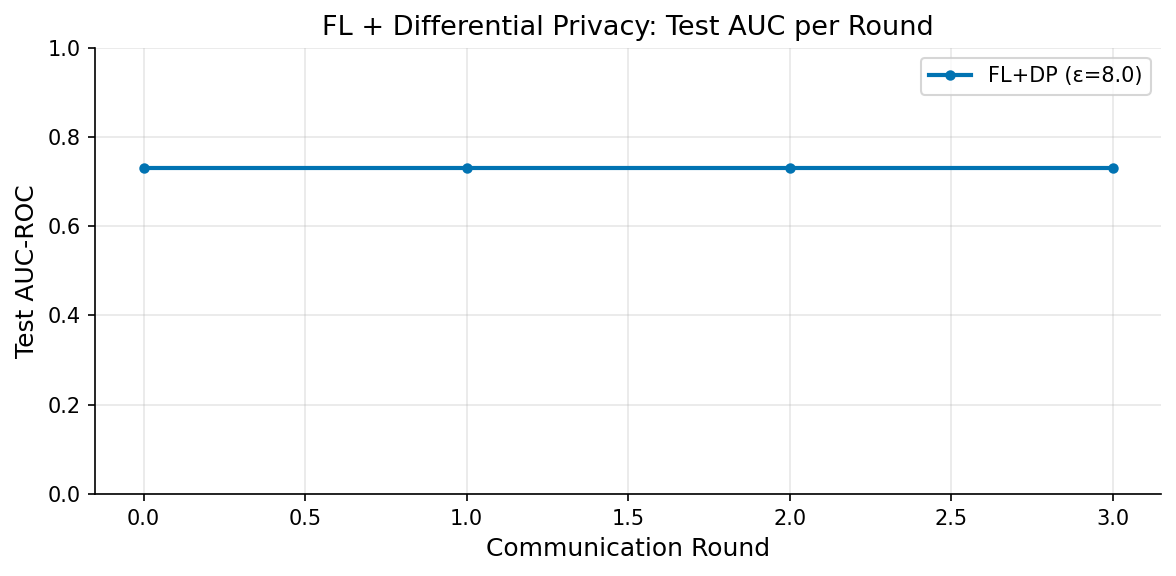

In [7]:
# Save results
fed_dir = paths["federated_model_dir"]
fed_dir.mkdir(parents=True, exist_ok=True)

dp_history_df = pd.DataFrame(fl_dp_round_results)
dp_history_df.to_csv(fed_dir / "fl_dp_history.csv", index=False)

# Final test evaluation
eval_model.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for images, labels, _ in test_loader:
        logits = eval_model(images.to(DEVICE))
        probs  = torch.softmax(logits, dim=1)[:, 1]
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

y_true_dp = np.array(all_labels)
y_prob_dp = np.array(all_probs)
np.save(fed_dir / "test_y_prob_dp.npy", y_prob_dp)
torch.save(eval_model.state_dict(), fed_dir / "global_model_dp.pth")

metrics = compute_metrics(y_true_dp, y_prob_dp)
print("FL+DP — Final Test Results:")
for k, v in metrics.items():
    if isinstance(v, float): print(f"  {k:25s}: {v:.4f}")

# Training curve
if len(dp_history_df) > 0:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(dp_history_df["round"], dp_history_df["test_auc"], "o-", lw=2, ms=4, label=f"FL+DP (ε={TARGET_EPS})")
    ax.set_xlabel("Communication Round"); ax.set_ylabel("Test AUC-ROC")
    ax.set_title("FL + Differential Privacy: Test AUC per Round")
    ax.set_ylim(0, 1); ax.grid(alpha=0.3); ax.legend()
    plt.tight_layout()
    save_figure(fig, "fl_dp_training_curves", paths["figures"], paths["paper_figures"])
    plt.show()